Fonte: https://www.ibm.com/br-pt/think/topics/support-vector-machine

https://medium.com/turing-talks/turing-talks-12-classifica%C3%A7%C3%A3o-por-svm-f4598094a3f1

https://uk.mathworks.com/discovery/support-vector-machine.html

Support Vector Machines (SVM) são algoritmos de aprendizado supervisionado que podem ser usados tanto para classificação quanto para regressão. O objetivo principal do SVM é encontrar a melhor fronteira de decisão que separa diferentes classes de dados com a maior margem possível.

Imagine que você tem dados de duas classes que podem ser separados por uma linha. Mas existem infinitas linhas que poderiam separar essas duas classes. O SVM encontra a linha que maximiza a distância entre os pontos mais próximos de cada classe.

**1. Conceitos Fundamentais**

O SVM funciona encontrando o hiperplano que melhor separa as classes. Para dados bidimensionais, esse hiperplano é uma linha. Para dados tridimensionais, é um plano. Para dimensões maiores, continuamos chamando de hiperplano.

Os pontos mais próximos à fronteira de decisão são chamados de **Support Vectors** (Vetores de Suporte). Estes são os pontos mais importantes porque determinam a posição da fronteira.

A **margem** é a distância entre a fronteira de decisão e os support vectors mais próximos. O SVM busca maximizar essa margem.

<img src="https://uk.mathworks.com/discovery/support-vector-machine/_jcr_content/mainParsys/band_1231704498_copy/mainParsys/lockedsubnav/mainParsys/columns/4d6875cb-8556-43eb-9393-53bcec9e3682/columns/29ee2f91-358a-4aca-8f04-e0f536feb8f2/image_2128876021_cop.adapt.full.medium.jpg/1759842383498.jpg">

**2. Kernel Trick**

Na prática, nem sempre os dados são linearmente separáveis. Nesses casos, o SVM usa o "kernel trick" para mapear os dados para um espaço de maior dimensão onde podem se tornar linearmente separáveis.

Tipos de kernels comuns:
- **Linear**: Para dados já linearmente separáveis
- **Polinomial**: Para dados com relacionamentos polinomiais  
- **RBF (Radial Basis Function)**: O mais comum, funciona bem para a maioria dos casos
- **Sigmoid**: Usado em casos específicos

**3. Parâmetros Importantes**

- **C (regularização)**: Controla o trade-off entre maximizar a margem e minimizar os erros de classificação
  - C alto: Margem menor, menos erros de treinamento
  - C baixo: Margem maior, mais tolerante a erros

- **Gamma** (para kernels RBF): Define quão longe a influência de um único exemplo de treinamento alcança
  - Gamma alto: Influência apenas de pontos próximos (pode causar overfitting)
  - Gamma baixo: Influência mais ampla (pode causar underfitting)

### 3.4.2 Intuição 

Vamos retornar com o Íris dataset:

**A ideia:**

Imagine que você encontrou uma flor íris na natureza e mediu suas caracteríristicas:
- Comprimento da pétala: 4.5 cm
- Largura da pétala: 1.5 cm

Existem 3 espécies de íris: Setosa, Versicolor e a Virginica.

Pergunta: **Qual espécie essa flor pertence?**

In [ ]:
# ================================================
# Bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

Iris data shape: (150, 2)

 Classes:
 0: setosa (50 samples)
 1: versicolor (50 samples)
 2: virginica (50 samples)


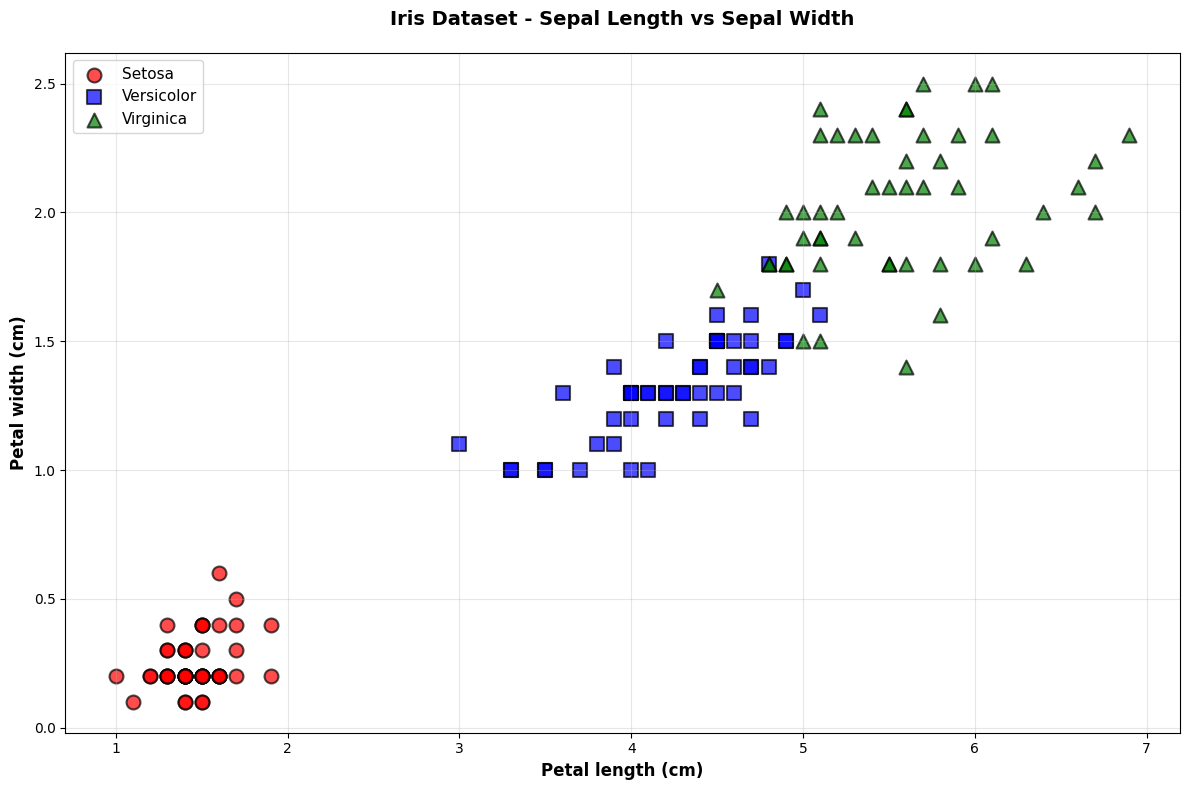

In [3]:
# =================================================
# 1. Análise Exploratória
# =================================================

iris = load_iris()
X = iris.data[:, [2, 3]] 
y = iris.target

print(f"Iris data shape: {X.shape}")
print(f"\n Classes:")
for i, name in enumerate(iris.target_names):
    count = np.sum(y == i)
    print(f" {i}: {name} ({count} samples)")

# Visualização dos dados
fig, ax = plt.subplots(figsize=(12, 8))

color = ['red', 'blue', 'green']
marker = ['o', 's', '^']

for i, name in enumerate(iris.target_names):
    indices = y == i
    ax.scatter(X[indices, 0], X[indices, 1], 
    c=color[i], marker=marker[i], s=100, alpha=0.7, 
    edgecolors='k', linewidth=1.5, label=name.capitalize())

ax.set_xlabel(iris.feature_names[2].capitalize(), fontsize=12, fontweight='bold')
ax.set_ylabel(iris.feature_names[3].capitalize(), fontsize=12, fontweight='bold')
ax.set_title('Iris Dataset - Sepal Length vs Sepal Width', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

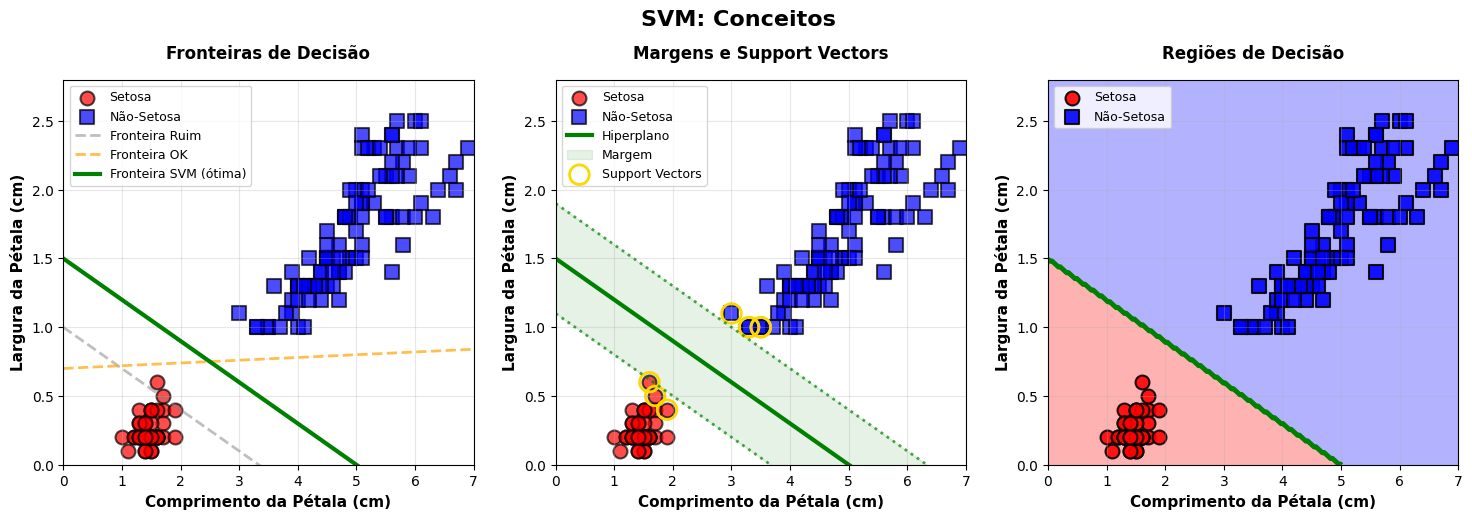

In [57]:
# =================================================
#2. Setosa vs Não-Setosa
# Ideia:
#  - Transformar o problema em binário para facilitar a visualização
#  - Setosa (0) vs Não-Setosa (1)
# =================================================

y_binary = (y != 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SVM: Conceitos', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Fronteiras de Decisão
ax1 = axes[0]

setosa_mask = y_binary == 0
not_setosa_mask = y_binary == 1

ax1.scatter(X[setosa_mask, 0], X[setosa_mask, 1],
            c='red', s=100, alpha=0.7, edgecolors='k', linewidth=1.5,
            label='Setosa', marker='o')

ax1.scatter(X[not_setosa_mask, 0], X[not_setosa_mask, 1],
            c='blue', s=100, alpha=0.7, edgecolors='k', linewidth=1.5,
            label='Não-Setosa', marker='s')

x_line = np.linspace(0, 7, 100)

y_line1 = -0.3 * x_line + 1
ax1.plot(x_line, y_line1, 'gray', linestyle='--', linewidth=2, alpha=0.5, label='Fronteira Ruim')

y_line2 = 0.02 * x_line + 0.7
ax1.plot(x_line, y_line2, 'orange', linestyle='--', linewidth=2, alpha=0.7, label='Fronteira OK')

y_line3 = -0.3 * x_line + 1.5
ax1.plot(x_line, y_line3, 'green', linestyle='-', linewidth=3, label='Fronteira SVM (ótima)')

ax1.set_xlabel('Comprimento da Pétala (cm)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Largura da Pétala (cm)', fontsize=11, fontweight='bold')
ax1.set_title('Fronteiras de Decisão', fontsize=12, fontweight='bold', pad=15)
ax1.legend(fontsize=9, loc='upper left')
ax1.set_xlim(0, 7)
ax1.set_ylim(0, 2.8)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Margens
ax2 = axes[1]

ax2.scatter(X[setosa_mask, 0], X[setosa_mask, 1],
            c='red', s=100, alpha=0.7, edgecolors='k', linewidth=1.5,
            label='Setosa', marker='o')

ax2.scatter(X[not_setosa_mask, 0], X[not_setosa_mask, 1],
            c='blue', s=100, alpha=0.7, edgecolors='k', linewidth=1.5,
            label='Não-Setosa', marker='s')

y_hyperplane = -0.3 * x_line + 1.5
ax2.plot(x_line, y_hyperplane, 'green', linestyle='-', linewidth=3,
         label='Hiperplano')

margin = 0.4
y_margin1 = y_hyperplane + margin
y_margin2 = y_hyperplane - margin

ax2.plot(x_line, y_margin1, 'green', linestyle=':', linewidth=2, alpha=0.7)
ax2.plot(x_line, y_margin2, 'green', linestyle=':', linewidth=2, alpha=0.7)
ax2.fill_between(x_line, y_margin1, y_margin2, color='green', alpha=0.1, 
                 label='Margem')

support_vectors = []
for i in range(len(X)):
    x_val, y_val = X[i]
    if 0 < x_val < 7:
        y_pred = -0.3 * x_val + 1.5
        if abs(y_val - y_pred) <= margin + 0.15:
            support_vectors.append(i)

if len(support_vectors) > 0:
    sv_points = X[support_vectors]
    ax2.scatter(sv_points[:, 0], sv_points[:, 1],
                s=200, facecolors='none', edgecolors='gold', linewidth=2,
                label='Support Vectors')
    
ax2.set_xlabel('Comprimento da Pétala (cm)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Largura da Pétala (cm)', fontsize=11, fontweight='bold')
ax2.set_title('Margens e Support Vectors', fontsize=12, fontweight='bold', pad=15)
ax2.legend(fontsize=9, loc='upper left')
ax2.set_xlim(0, 7)
ax2.set_ylim(0, 2.8)
ax2.grid(True, alpha=0.3)

# Gráfico 3: Regiões de Decisão
ax3 = axes[2]

x_min, x_max = 0, 7
y_min, y_max = 0, 2.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

Z = (yy > (-0.3 * xx + 1.5)).astype(int)

ax3.contourf(xx, yy, Z, alpha=0.3, levels=1, colors=['red', 'blue'])
ax3.contour(xx, yy, Z, levels=1, colors='green', linewidths=3)
ax3.scatter(X[setosa_mask, 0], X[setosa_mask, 1],
            c='red', s=100, alpha=0.9, edgecolors='k', linewidth=1.5,
            label='Setosa', marker='o')
ax3.scatter(X[not_setosa_mask, 0], X[not_setosa_mask, 1],
            c='blue', s=100, alpha=0.9, edgecolors='k', linewidth=1.5,
            label='Não-Setosa', marker='s')

ax3.set_xlabel('Comprimento da Pétala (cm)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Largura da Pétala (cm)', fontsize=11, fontweight='bold')
ax3.set_title('Regiões de Decisão', fontsize=12, 
              fontweight='bold', pad=15)
ax3.legend(fontsize=9, loc='upper left')
ax3.set_xlim(0, 7)
ax3.set_ylim(0, 2.8)
ax3.grid(True, alpha=0.3)

---

**Vamos dificultar um pouco mais o problema**

**E se os dados não forem linearmente separáveis?**
- e.g., Cículos côncêntricos
    - Classe Vermelha: Círculo interior
    - Classe Azul: Círculo exterior

Vamos fazer isso!

---



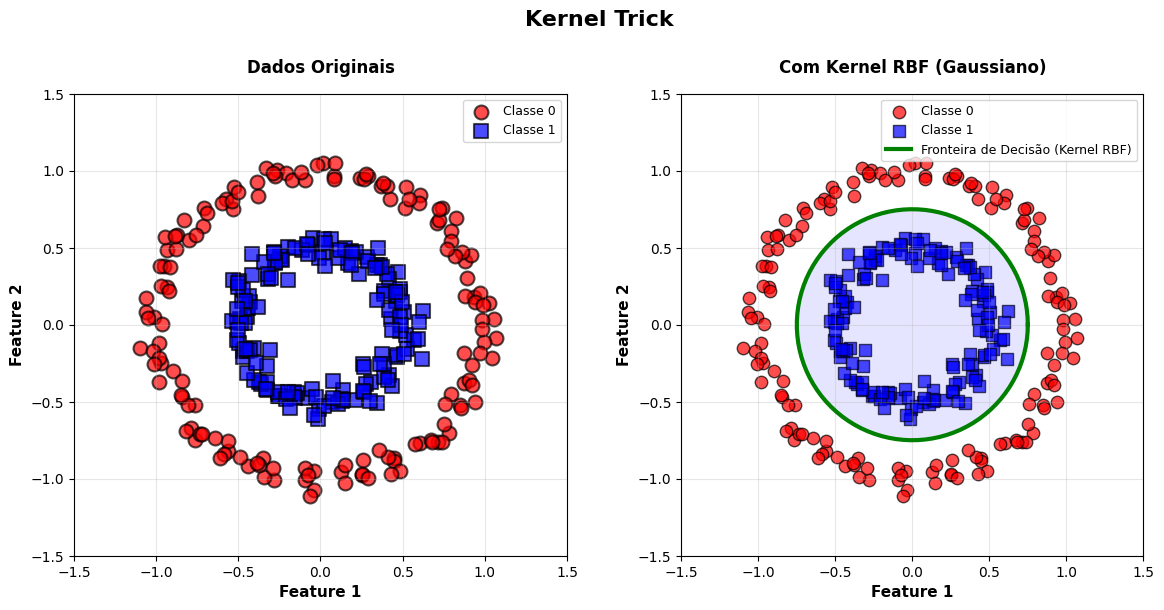

In [97]:
# =================================================
# 3. Kernel Trick

# Ideia:
# - Projete os dados em um espaço de dimensão maior
# - Lá, eles se tornam linearmente separáveis
# - Encontre o hiperplano nesse novo espaço
# - Volte para o espaço original
# =================================================

from sklearn.datasets import make_circles   

X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Kernel Trick', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Dados Originais
ax1 = axes[0]

ax1.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1],
            c='red', s=100, alpha=0.7, edgecolors='k', linewidth=1.5,
            label='Classe 0', marker='o')
ax1.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1],
            c='blue', s=100, alpha=0.7, edgecolors='k', linewidth=1.5,
            label='Classe 1', marker='s')

ax1.set_xlabel('Feature 1', fontsize=11, fontweight='bold')
ax1.set_ylabel('Feature 2', fontsize=11, fontweight='bold')
ax1.set_title('Dados Originais', fontsize=12, fontweight='bold', pad=15)
ax1.legend(fontsize=9, loc='upper right')
ax1.set_xlim(-1.5, 1.5)
ax1.set_ylim(-1.5, 1.5)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Com Kernel RBF (Gaussiano)
ax2 = axes[1]

ax2.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1],
            c='red', s=80, alpha=0.7, edgecolors='k', linewidth=1,
            label='Classe 0', marker='o')
ax2.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1],
            c='blue', s=80, alpha=0.7, edgecolors='k', linewidth=1,
            label='Classe 1', marker='s')

# Desenhar fronteira de decisão circular (resultado do kernel RBF (você verá isso mais tarde))
theta_circle = np.linspace(0, 2 * np.pi, 100)
r_boundary = 0.75
x_boundary = r_boundary * np.cos(theta_circle)
y_boundary = r_boundary * np.sin(theta_circle)
ax2.plot(x_boundary, y_boundary, 'green', linestyle='-', linewidth=3,
            label='Fronteira de Decisão (Kernel RBF)')

# Áreas de decisão
circle = plt.Circle((0, 0), r_boundary, alpha=0.1, color='blue')
ax2.add_patch(circle)
ax2.fill_between([0], [0], [0], color='blue', alpha=0.3)



ax2.set_xlabel('Feature 1', fontsize=11, fontweight='bold')
ax2.set_ylabel('Feature 2', fontsize=11, fontweight='bold')
ax2.set_title('Com Kernel RBF (Gaussiano)', fontsize=12, fontweight='bold', pad=15)
ax2.legend(fontsize=9, loc='upper right')
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', 'box')

plt.show()

### 3.4.3 Formulação Formal

**Entrada**

1. Conjunto de treinamento de n amostras em pares $D=\{(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), ..., (x^{(n)}, y^{(n)})\}$

    onde:

    - $x^{(i)}$: vetor de d features ($x^{(i)} = (x^{(i)}_1, x^{(i)}_2, ..., x^{(i)}_d)$), portanto $x^{(i)} \in \mathbb{R}^d$

    - $y^{(i)}$: rótulo de classe binário, ou seja, $y^{(i)} \in \{-1, +1\}$ (diferente dos outros algoritmos que usam {0,1})

**Processamento**

O objetivo é encontrar o hiperplano que separa as classes com a maior margem possível.

**1. Hiperplano de Separação**

O hiperplano é definido por:

$\mathbf{w}^T\mathbf{x} + b = 0$

onde $\mathbf{w}$ é o vetor normal ao hiperplano e $b$ é o bias.

Para classificação:
- Se $\mathbf{w}^T\mathbf{x} + b > 0$, então $\hat{y} = +1$
- Se $\mathbf{w}^T\mathbf{x} + b < 0$, então $\hat{y} = -1$

**2. Margem**

A distância de um ponto $\mathbf{x}^{(i)}$ ao hiperplano é:

$\text{distância} = \frac{|\mathbf{w}^T\mathbf{x}^{(i)} + b|}{||\mathbf{w}||}$

Para os pontos corretamente classificados:
$y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)} + b) \geq 1$

A margem total é $\frac{2}{||\mathbf{w}||}$

**3. Problema de Otimização (Hard Margin)**

Para dados linearmente separáveis, queremos maximizar a margem:

$\max_{\mathbf{w}, b} \frac{2}{||\mathbf{w}||} \Leftrightarrow \min_{\mathbf{w}, b} \frac{1}{2}||\mathbf{w}||^2$

Sujeito a: $y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)} + b) \geq 1$ para $i = 1, ..., n$

**4. Soft Margin (Dados não Separáveis)**

Para dados não linearmente separáveis, introduzimos variáveis de folga $\xi_i$:

$\min_{\mathbf{w}, b, \xi} \frac{1}{2}||\mathbf{w}||^2 + C\sum_{i=1}^{n}\xi_i$

Sujeito a:
- $y^{(i)}(\mathbf{w}^T\mathbf{x}^{(i)} + b) \geq 1 - \xi_i$
- $\xi_i \geq 0$

onde $C$ é o parâmetro de regularização que controla o trade-off entre maximizar a margem e minimizar os erros.

**5. Kernel Trick**

Para dados não linearmente separáveis, mapeamos para um espaço de maior dimensão usando funções kernel:

$K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) = \phi(\mathbf{x}^{(i)})^T\phi(\mathbf{x}^{(j)})$

Kernels comuns:

- **Linear**: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T\mathbf{x}_j$

- **Polinomial**: $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\mathbf{x}_i^T\mathbf{x}_j + r)^d$

- **RBF (Gaussiano)**: $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma||\mathbf{x}_i - \mathbf{x}_j||^2)$

- **Sigmoid**: $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma\mathbf{x}_i^T\mathbf{x}_j + r)$

**Saída - Classificação**

- **Parâmetros do Modelo**: Vetores de suporte e seus coeficientes $\alpha_i$

- **Função de Decisão**: $f(\mathbf{x}) = \sum_{i \in SV} \alpha_i y^{(i)} K(\mathbf{x}^{(i)}, \mathbf{x}) + b$

- **Predição**: $\hat{y} = \text{sign}(f(\mathbf{x}))$

onde $SV$ representa o conjunto de índices dos vetores de suporte.


Saiba Mais: https://medium.com/data-science/the-kernel-trick-c98cdbcaeb3f

### 3.4.4 Desafio: "From Scratch"

Vamos implementar uma versão simplificada do algoritmo SVM do zero

In [104]:
class SimpleSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iterations=1000):
        """
        Implementação simplificada do SVM usando gradiente descendente.
        
        Parâmetros:
        -----------
        learning_rate: float
            Taxa de aprendizagem para o gradiente descendente.
        lambda_param: float 
            Parâmetro de regularização (equivalente a 1/C no sklearn).
        n_iterations: int
            Número de iterações para treinamento.
        """
        pass

    def fit(self, X, y):
        """
        Treina o modelo SVM.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características de forma (n_samples, n_features).
        y: np.ndarray
            Labels das classes (-1 ou +1).
        """
        pass

    def predict(self, X):
        """
        Faz predições para novos dados.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
            
        Retorna:
        --------
        np.ndarray
            Predições (-1 ou +1).
        """
        pass

    def decision_function(self, X):
        """
        Calcula a função de decisão (distância ao hiperplano).
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
            
        Retorna:
        --------
        np.ndarray
            Valores da função de decisão.
        """
        pass

    def score(self, X, y):
        """
        Calcula a acurácia do modelo.
        
        Parâmetros:
        -----------
        X: np.ndarray
            Matriz de características.
        y: np.ndarray
            Labels verdadeiros.
            
        Retorna:
        --------
        float
            Acurácia do modelo.
        """
        pass

In [103]:
# Dados para Teste
# ==================================================
from sklearn.model_selection import train_test_split
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  "Titanic-Dataset.csv",
  pandas_kwargs={"encoding": "latin", "usecols": [1, 2, 4, 5]}
)

# Preparar os dados
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].mean())

X = df[['Pclass', 'Sex', 'Age']].values
y = df['Survived'].values

# Converter para formato SVM (-1, +1)
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.4.5 Usando SKlearn

In [105]:
# Carregando os dados (novamente)
# ==================================================
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "yasserh/titanic-dataset",
  "Titanic-Dataset.csv",
  pandas_kwargs={"encoding": "latin", "usecols": [1, 2, 4, 5]}
)

# Preparar os dados
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].mean())

X = df[['Pclass', 'Sex', 'Age']].values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
# =================================================
# Biliotecas

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [107]:
# =================================================
# 1. Básico - SVM Linear

# Ideia:
# - Normalizar features (MUITO IMPORTANTE para SVM)
# - Treinar o modelo
# =================================================

# Normalizar os dados (crucial para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SVM básico com kernel linear
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred = svm.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Linear - Acurácia: {accuracy*100:.2f}%")

# Informações sobre o modelo
print(f"Número de Support Vectors: {svm.n_support_}")
print(f"Total de Support Vectors: {len(svm.support_)}")
print(f"Proporção de Support Vectors: {len(svm.support_)/len(X_train)*100:.1f}%")

SVM Linear - Acurácia: 78.21%
Número de Support Vectors: [155 158]
Total de Support Vectors: 313
Proporção de Support Vectors: 44.0%


In [108]:
# =================================================
# 2. Testando Diferentes Kernels

# Kernels disponíveis no sklearn:
# - 'linear': para dados linearmente separáveis
# - 'poly': kernel polinomial
# - 'rbf': Radial Basis Function (Gaussiano) - default
# - 'sigmoid': kernel sigmoide
# =================================================

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []

for kernel in kernels:
    # Treinar SVM com kernel específico
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    
    # Avaliar
    y_pred = svm.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append((kernel, accuracy, len(svm.support_)))
    print(f"Kernel {kernel:8}: Acurácia = {accuracy*100:5.2f}%, Support Vectors = {len(svm.support_):3d}")

print(f"\nMelhor kernel: {max(results, key=lambda x: x[1])[0]}")

Kernel linear  : Acurácia = 78.21%, Support Vectors = 313
Kernel poly    : Acurácia = 79.33%, Support Vectors = 317
Kernel rbf     : Acurácia = 77.09%, Support Vectors = 318
Kernel sigmoid : Acurácia = 74.30%, Support Vectors = 264

Melhor kernel: poly


In [109]:
# =================================================
# 3. Parâmetros Importantes do SVM

# C (default=1.0): Parâmetro de regularização
# - C alto: Margem menor, menos tolerância a erros (pode causar overfitting)
# - C baixo: Margem maior, mais tolerância a erros (pode causar underfitting)

# gamma (para kernels RBF, poly, sigmoid): Define a influência de cada exemplo
# - gamma alto: Influência apenas de pontos próximos (pode causar overfitting)  
# - gamma baixo: Influência mais ampla (pode causar underfitting)
# - 'scale' (default): 1 / (n_features * X.var())
# - 'auto': 1 / n_features

# degree (para kernel poly): Grau do polinômio

# kernel: Tipo de kernel a ser usado
# =================================================

# Testar diferentes valores de C
C_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

print("Testando parâmetro C (com kernel RBF):")
for C in C_values:
    svm = SVC(kernel='rbf', C=C, random_state=42)
    svm.fit(X_train_scaled, y_train)
    accuracy = svm.score(X_test_scaled, y_test)
    print(f"C = {C:5.1f}: Acurácia = {accuracy*100:5.2f}%, Support Vectors = {len(svm.support_):3d}")

print(f"\nTestando parâmetro gamma (com kernel RBF, C=1):")
for gamma in gamma_values:
    svm = SVC(kernel='rbf', C=1, gamma=gamma, random_state=42)
    svm.fit(X_train_scaled, y_train)
    accuracy = svm.score(X_test_scaled, y_test)
    print(f"gamma = {str(gamma):5}: Acurácia = {accuracy*100:5.2f}%, Support Vectors = {len(svm.support_):3d}")

Testando parâmetro C (com kernel RBF):
C =   0.1: Acurácia = 78.21%, Support Vectors = 375
C =   1.0: Acurácia = 77.09%, Support Vectors = 318
C =  10.0: Acurácia = 78.21%, Support Vectors = 314
C = 100.0: Acurácia = 77.65%, Support Vectors = 317

Testando parâmetro gamma (com kernel RBF, C=1):
gamma = scale: Acurácia = 77.09%, Support Vectors = 318
gamma = auto : Acurácia = 77.09%, Support Vectors = 318
gamma = 0.001: Acurácia = 78.21%, Support Vectors = 537
gamma = 0.01 : Acurácia = 78.21%, Support Vectors = 354
gamma = 0.1  : Acurácia = 78.21%, Support Vectors = 321
gamma = 1    : Acurácia = 79.33%, Support Vectors = 327


In [111]:
# =================================================
# 4. Otimização de Hiperparâmetros com Grid Search
# =================================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Definir espaço de busca
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

# Grid search com validação cruzada
svm_grid = SVC(random_state=42)
grid_search = GridSearchCV(svm_grid, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Melhores parâmetros
print(f"Melhores parâmetros: {grid_search.best_params_}")
print(f"Melhor score CV: {grid_search.best_score_*100:.2f}%")

# Avaliar no conjunto de teste
best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Acurácia no teste: {accuracy_best*100:.2f}%")

# Relatório detalhado
print(f"\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Melhores parâmetros: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Melhor score CV: 80.61%
Acurácia no teste: 79.33%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       105
           1       0.82      0.64      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179



Predições para casos específicos:
Caso 1:
  Classe: 1ª classe
  Sexo: Feminino
  Idade: 25 anos
  Predição: Sobrevive
  Confiança: 1.007
  ****************************************
Caso 2:
  Classe: 3ª classe
  Sexo: Masculino
  Idade: 22 anos
  Predição: Não Sobrevive
  Confiança: 1.000
  ****************************************
Caso 3:
  Classe: 2ª classe
  Sexo: Feminino
  Idade: 35 anos
  Predição: Sobrevive
  Confiança: 1.003
  ****************************************
Caso 4:
  Classe: 3ª classe
  Sexo: Feminino
  Idade: 5 anos
  Predição: Sobrevive
  Confiança: 0.084
  ****************************************


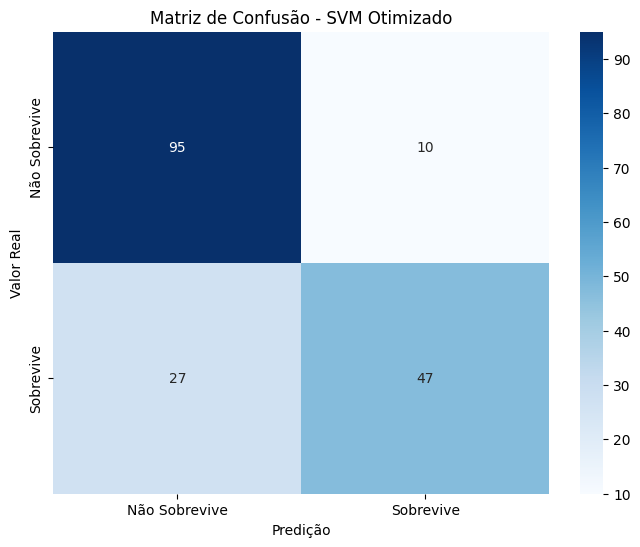

In [114]:
# =================================================
# 5. Interpretação dos Resultados

# Vamos analisar as predições para alguns casos específicos
# =================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Casos de teste específicos
test_cases = [
    [1, 1, 25],  # 1ª classe, feminino, 25 anos - deveria sobreviver
    [3, 0, 22],  # 3ª classe, masculino, 22 anos - provavelmente não sobrevive
    [2, 1, 35],  # 2ª classe, feminino, 35 anos - provavelmente sobrevive
    [3, 1, 5],   # 3ª classe, feminino, 5 anos - criança, provavelmente sobrevive
]

print("Predições para casos específicos:")
print("=" * 60)

for i, case in enumerate(test_cases):
    # Normalizar o caso de teste
    case_scaled = scaler.transform([case])
    
    # Fazer predição
    prediction = best_svm.predict(case_scaled)[0]
    confidence = best_svm.decision_function(case_scaled)[0]
    
    # Mapear características
    class_names = {1: "1ª classe", 2: "2ª classe", 3: "3ª classe"}
    sex_names = {0: "Masculino", 1: "Feminino"}
    result_names = {0: "Não Sobrevive", 1: "Sobrevive"}
    
    print(f"Caso {i+1}:")
    print(f"  Classe: {class_names[case[0]]}")
    print(f"  Sexo: {sex_names[case[1]]}")
    print(f"  Idade: {case[2]} anos")
    print(f"  Predição: {result_names[prediction]}")
    print(f"  Confiança: {abs(confidence):.3f}")
    print(f"  {'*' * 40}")

# Matriz de confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Não Sobrevive', 'Sobrevive'],
            yticklabels=['Não Sobrevive', 'Sobrevive'])
plt.title('Matriz de Confusão - SVM Otimizado')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

### 3.4.6 Conclusões e Considerações

**Vantagens do SVM:**

1. **Eficaz em Espaços de Alta Dimensão**: Funciona bem mesmo quando o número de features é maior que o número de amostras

2. **Uso Eficiente de Memória**: Usa apenas os support vectors para fazer predições, não todos os dados de treinamento

3. **Versátil**: Diferentes kernels permitem capturar relacionamentos complexos entre as features

4. **Robusto a Overfitting**: Especialmente em espaços de alta dimensão

**Desvantagens do SVM:**

1. **Não Fornece Estimativas de Probabilidade**: Por padrão, SVM não calcula probabilidades (embora possa ser habilitado com `probability=True`)

2. **Sensível à Escala das Features**: Requer normalização dos dados

3. **Escolha do Kernel e Parâmetros**: Requer experimentação para encontrar os melhores hiperparâmetros

4. **Lento em Conjuntos Grandes**: Complexidade computacional pode ser alta para datasets muito grandes

**Aplicações Comuns do SVM:**

- Classificação de texto e análise de sentimento
- Classificação de imagens
- Reconhecimento de padrões bioinformáticos  
- Detecção de fraude
- Classificação de documentos

**Dicas Práticas:**

1. **Sempre normalize os dados** antes de usar SVM
2. **Comece com kernel RBF** para a maioria dos problemas
3. **Use Grid Search** para encontrar os melhores parâmetros
4. **Para datasets grandes**, considere usar `LinearSVC` ou `SGDClassifier`
5. **Para problemas multiclasse**, SVM usa estratégias como "one-vs-one" automaticamente